In [1]:
import pandas as pd
import os
from plotnine import *

import numpy as np
from pyensembl import EnsemblRelease
from matplotlib import gridspec, rc, rcParams
import matplotlib.pyplot as plt
import patchworklib as pw

<Figure size 72x72 with 0 Axes>

In [2]:
fig_size_set = (10,6)
font_size = 28

In [3]:
#Set working directory
working_dir="/projects/b1042/AmaralLab/Maalavika/TF_Positional_Distribution_Model/data/Goode_ESC/"
os.chdir(working_dir)

# Change in number of peaks and edges across reference genomes

In [4]:
os.chdir('mm10')
peaks = pd.read_csv('CompiledUnreplicatedPeaks.csv',index_col =0)
edges= pd.read_csv('CompiledUnreplicatedEdges.csv',index_col =0)

In [5]:
peaks.pval = pd.Categorical(peaks.pval)
p1 = (ggplot(data = peaks)+
 geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfPeaks/1000', fill = 'pval'), width= 0.5,position=position_dodge(width=0.75)) + 
 geom_point(aes(x = 'CellType', y ='NumberOfPeaks/1000', fill = 'pval'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of peaks (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"))+
 scale_fill_discrete(guide=False)+
 scale_fill_brewer(palette='Blues',guide=False)

)
p1 =  pw.load_ggplot(p1, figsize=fig_size_set)

In [6]:
edges.pval = pd.Categorical(edges.pval)
e1 = (ggplot(data = edges.loc[edges.Flank == 'cds'])+
geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'pval'), width= 0.5,
              position=position_dodge(width=0.75), show_legend=False) + 
 geom_point(aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'pval'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of edges (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"),
      legend_direction='horizontal',
        legend_position='bottom')+
 scale_fill_brewer(palette='Blues')+
 guides(fill = guide_legend(order=1,override_aes={"shape": 's', 'size': 8},
                           nrow=1, byrow = True))
)
e1 = pw.load_ggplot(e1, figsize=fig_size_set)

In [7]:
os.chdir('../mm39/')
peaks_mm39=pd.read_csv('CompiledUnreplicatedPeaks.csv', index_col =0)
edges_mm39=pd.read_csv('CompiledUnreplicatedEdges.csv', index_col =0)

In [8]:
p2=(ggplot(data = peaks_mm39)+
 geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfPeaks/1000', fill = 'Genome'), width= 0.5,position=position_dodge(width=0.75)) + 
 geom_point(aes(x = 'CellType', y ='NumberOfPeaks/1000', fill = 'Genome'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of peaks (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"))+
 scale_fill_discrete(guide=False)+
 scale_fill_brewer(palette='Blues',guide=False)

)

p2= pw.load_ggplot(p2, figsize=fig_size_set)

In [9]:
e2=(ggplot(data = edges_mm39)+
 geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Genome'), width= 0.5,position=position_dodge(width=0.75),
             show_legend=False) + 
 geom_point(aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Genome'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of edges (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"),
      legend_direction='horizontal',
        legend_position='bottom')+
 scale_fill_brewer(palette='Blues')+
 guides(fill = guide_legend(order=1,override_aes={"shape": 's', 'size': 8},
                           nrow=1, byrow = True))
)
e2= pw.load_ggplot(e2, figsize=fig_size_set)

## Change in number of peaks and edges for different flank size

In [32]:
os.chdir('../mm10')

os.chdir('1e-5')


peak_stats=pd.read_csv('CompiledUnreplicatedPeaks.csv',index_col = 0)
edges_stats=pd.read_csv('CompiledUnreplicatedEdges.csv',index_col = 0)

In [ ]:
peak_stats=peak_stats.loc[peak_stats.Flank!='cds']
peak_stats['Flank'] =peak_stats['Flank'].astype(str)
peak_stats['Flank'] = pd.Categorical(peak_stats['Flank'] , categories =['0', '1000', '2000', '3000', 
                                                                        '4000',  '5000', '6000',  '7000',
                                                                        '8000', '9000','10000'])
peak_stats.NumberOfEdges = peak_stats.NumberOfEdges.astype(int)
p3=(ggplot(data = peak_stats)+
 geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Flank'), width= 0.5,position=position_dodge(width=0.75)) + 
 geom_point(aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Flank'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of peaks (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"))+
 scale_fill_discrete(guide=False)+
 scale_fill_brewer(palette='Blues',guide=False)

)

p3= pw.load_ggplot(p3, figsize=fig_size_set)


In [ ]:
peak_stats

In [12]:
edges_stats=edges_stats.loc[edges_stats.Flank!='cds']
edges_stats['Flank (kbp)'] =edges_stats['Flank'].astype(float)/1000
edges_stats['Flank (kbp)'] =edges_stats['Flank (kbp)'].astype(str)
edges_stats['Flank (kbp)'] = pd.Categorical(edges_stats['Flank (kbp)'] , categories =['0.0', '1.0', '2.0', '3.0', 
                                                                        '4.0',  '5.0', '6.0',  '7.0',
                                                                        '8.0', '9.0','10.0'])
edges_stats['NumberOfEdges'] =edges_stats['NumberOfEdges'].astype(int)
e3=(ggplot(data = edges_stats)+
 geom_boxplot(mapping = aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Flank (kbp)'), width= 0.5,position=position_dodge(width=0.75),
             show_legend=False) + 
 geom_point(aes(x = 'CellType', y ='NumberOfEdges/1000', fill = 'Flank (kbp)'),alpha = 0.5,position=position_dodge(width=0.75)) +
 scale_y_continuous(trans='log10')+
 theme_classic()+
 ylab("Number of edges (thousands)")+
 xlab("Cell Type")+
 theme(text=element_text(size=font_size), figure_size=(10, 6), 
      panel_grid_major_y=element_line(linetype="dashed"),
      legend_direction='horizontal',
        legend_position='bottom')+
 scale_fill_brewer(palette='Blues')+
 guides(fill = guide_legend(order=1,override_aes={"shape": 's', 'size': 8},
                           nrow=1, byrow = True))
)

e3= pw.load_ggplot(e3, figsize=fig_size_set)


In [13]:
os.chdir('../../raw')
counts = pd.read_csv('processed_edge_counts.csv',index_col=0)
counts['_merge'] = pd.Categorical(counts['_merge'], categories = ['Only us', 'both', 'Only Goode et al.'])

In [14]:
p_count = (ggplot(counts)+ 
    geom_col(aes(x = 'CellType', y = 'count', fill = '_merge'), color = "black", stat='summary', position='dodge')+
    theme_classic()+
    theme(text = element_text(size =font_size),panel_grid_major_y=element_line(linetype="dashed"),
          legend_direction='horizontal',
            legend_position='top')+
     guides(fill = guide_legend(order=1,override_aes={"shape": 's'},
                               nrow=1, byrow = True))+
    scale_fill_manual(values=[ '#446AC1', '#834DA7', '#BF5C6B'])+
    labs(fill = 'Class') + 
    ylab('Number of network edges')+
    xlab('Cell Type'))
p_count= pw.load_ggplot(p_count, figsize=(10,6))

In [15]:
abs_edges=pd.read_csv('Compiled_absent_edges.csv',index_col=0)
abs_edges['min_dist'] =abs_edges['min_dist']/1000
mean_dist = 'Mean = '+ str(int(abs_edges.min_dist.mean())) +'kbp'
median_dist = 'Median = ' + str(int(abs_edges.min_dist.median())) +'kbp'

In [16]:
abs_edges['min_dist'] = np.log10(abs_edges['min_dist'])
bins=max(abs_edges['min_dist'].round()) 
his = (ggplot(abs_edges)+
geom_histogram(aes(x='min_dist'), fill = '#BF5C6B', color = "black", binwidth =1)+
xlab('log10Distance of closest peak(kbp)')+
ylab('Number of network edges \n only in Goode et al.')+
annotate('text', x=4, y = 14, label= mean_dist, size= font_size)+
annotate('text', x=4, y = 12, label= median_dist, size= font_size)+
scale_x_continuous(limits=(0, bins+2))+
theme_classic()+
theme(text=element_text(size=font_size), figure_size=(10, 6),
      panel_grid_major_y=element_line(linetype="dashed")
))
his= pw.load_ggplot(his, figsize=(10,6))

In [17]:
p2.set_index('(a)',size = 28,fontweight="bold")
p1.set_index('(a)',size = 28,fontweight="bold")
p3.set_index('(a)',size = 28,fontweight="bold")
e2.set_index('(b)',size = 28,fontweight="bold")
e1.set_index('(b)',size = 28,fontweight="bold")
e3.set_index('(b)',size = 28,fontweight="bold")
p_count.set_index('(a)',size = 28,fontweight="bold")
his.set_index('(b)',size = 28,fontweight="bold")

Text(-0.0, 1.0, '(b)')

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:name pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closing glyph list over 'glyf': 8 glyphs before
INFO:fontTool

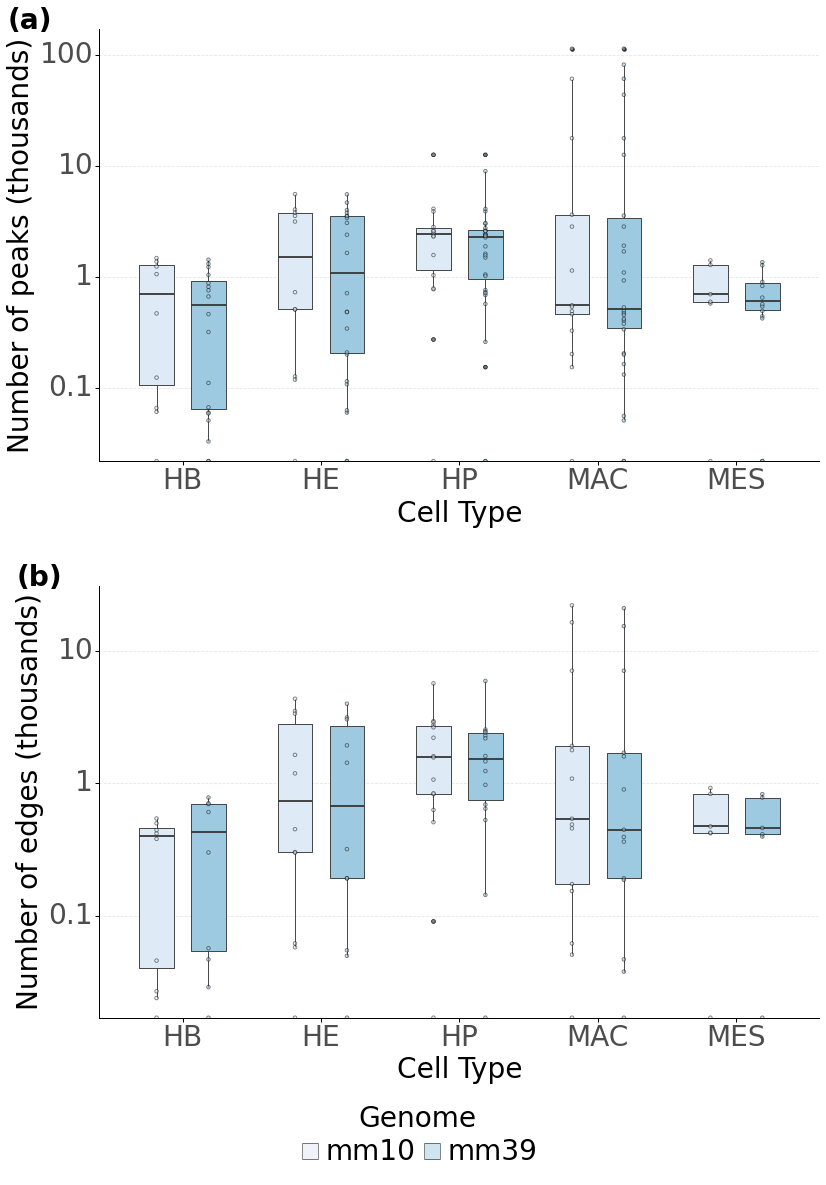

In [18]:
s1 = p2/e2
s1.savefig('../../../Figures/SFig1.pdf')

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:name pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closing glyph list over 'glyf': 8 glyphs before
INFO:fontTool

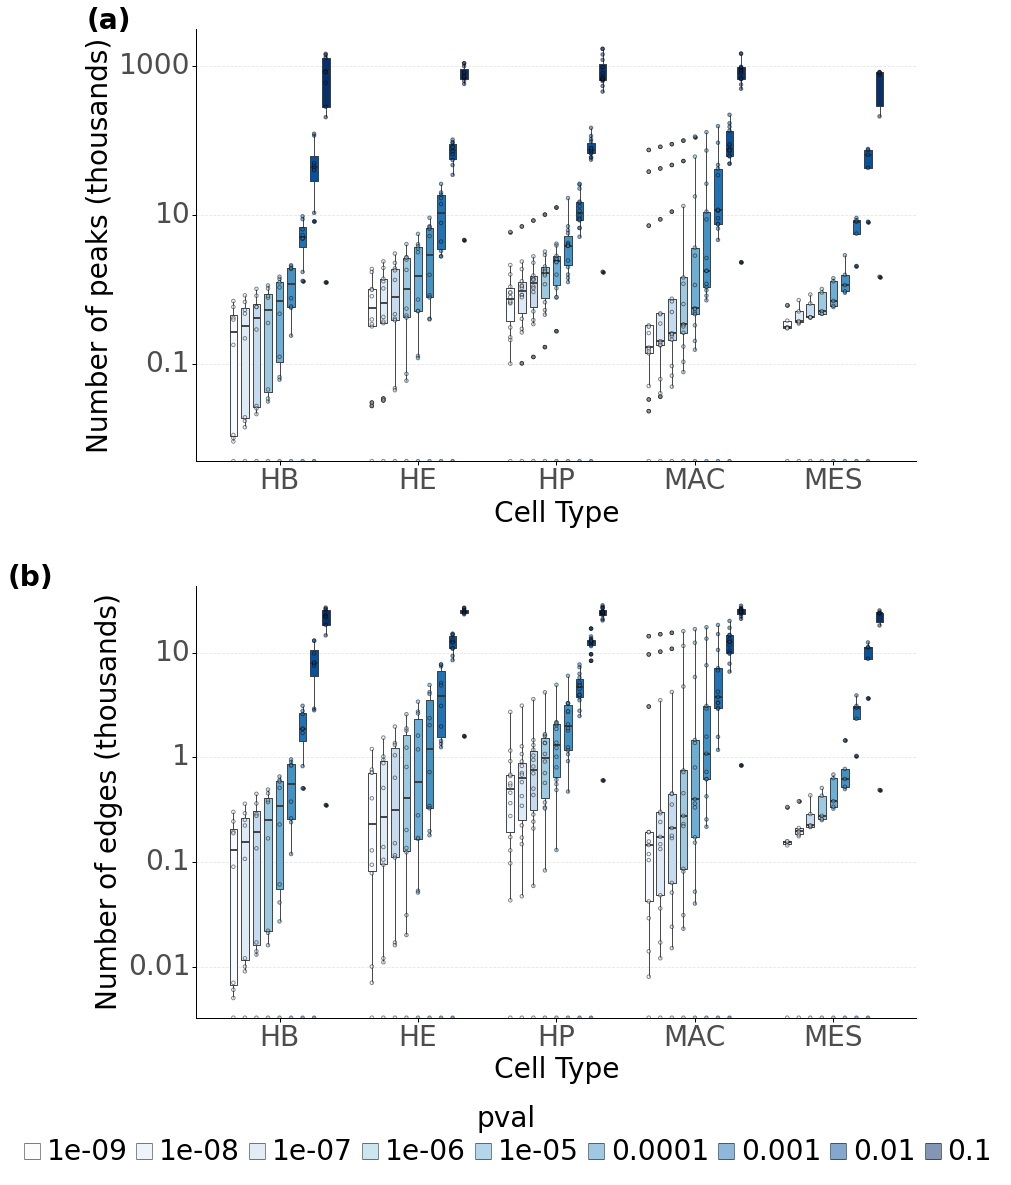

In [19]:
s2 = p1/e1
s2.savefig('../../../Figures/SFig2.pdf')

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:name pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closing glyph list over 'glyf': 8 glyphs before
INFO:fontTool

INFO:fontTools.subset:GSUB pruned


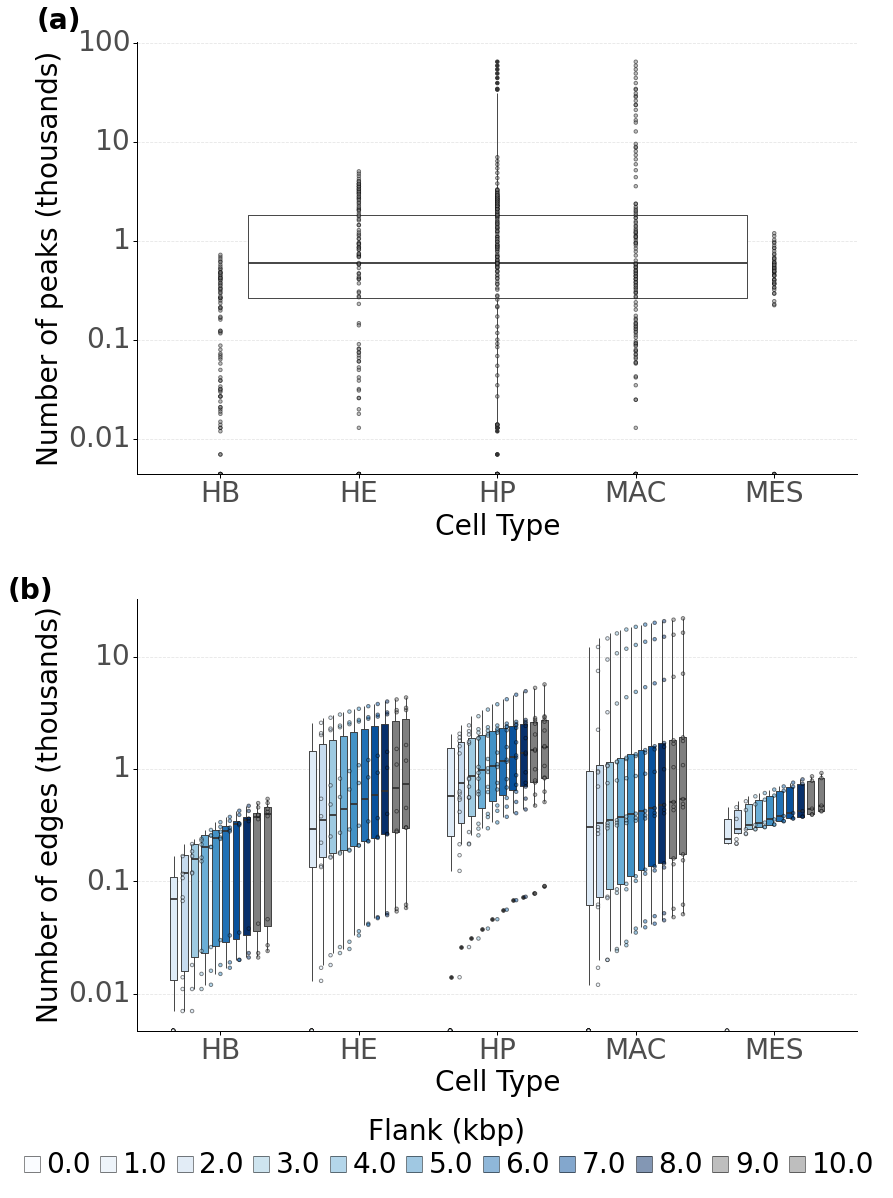

In [20]:
s3 = p3/e3
s3.savefig('../../../Figures/SFig3.pdf')

INFO:fontTools.subset:maxp pruned
INFO:fontTools.subset:cmap pruned
INFO:fontTools.subset:kern dropped
INFO:fontTools.subset:post pruned
INFO:fontTools.subset:FFTM dropped
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned
INFO:fontTools.subset:name pruned
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:Added gid0 to subset
INFO:fontTools.subset:Added first four glyphs to subset
INFO:fontTools.subset:Closing glyph list over 'GSUB': 8 glyphs before
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closed glyph list over 'GSUB': 8 glyphs after
INFO:fontTools.subset:Glyph names: ['.notdef', '.null', 'a', 'b', 'nonmarkingreturn', 'parenleft', 'parenright', 'space']
INFO:fontTools.subset:Glyph IDs:   [0, 1, 2, 3, 11, 12, 68, 69]
INFO:fontTools.subset:Closing glyph list over 'glyf': 8 glyphs before
INFO:fontTool

INFO:fontTools.subset:OS/2 Unicode ranges pruned: [0]
INFO:fontTools.subset:glyf pruned
INFO:fontTools.subset:GDEF pruned
INFO:fontTools.subset:GPOS pruned
INFO:fontTools.subset:GSUB pruned


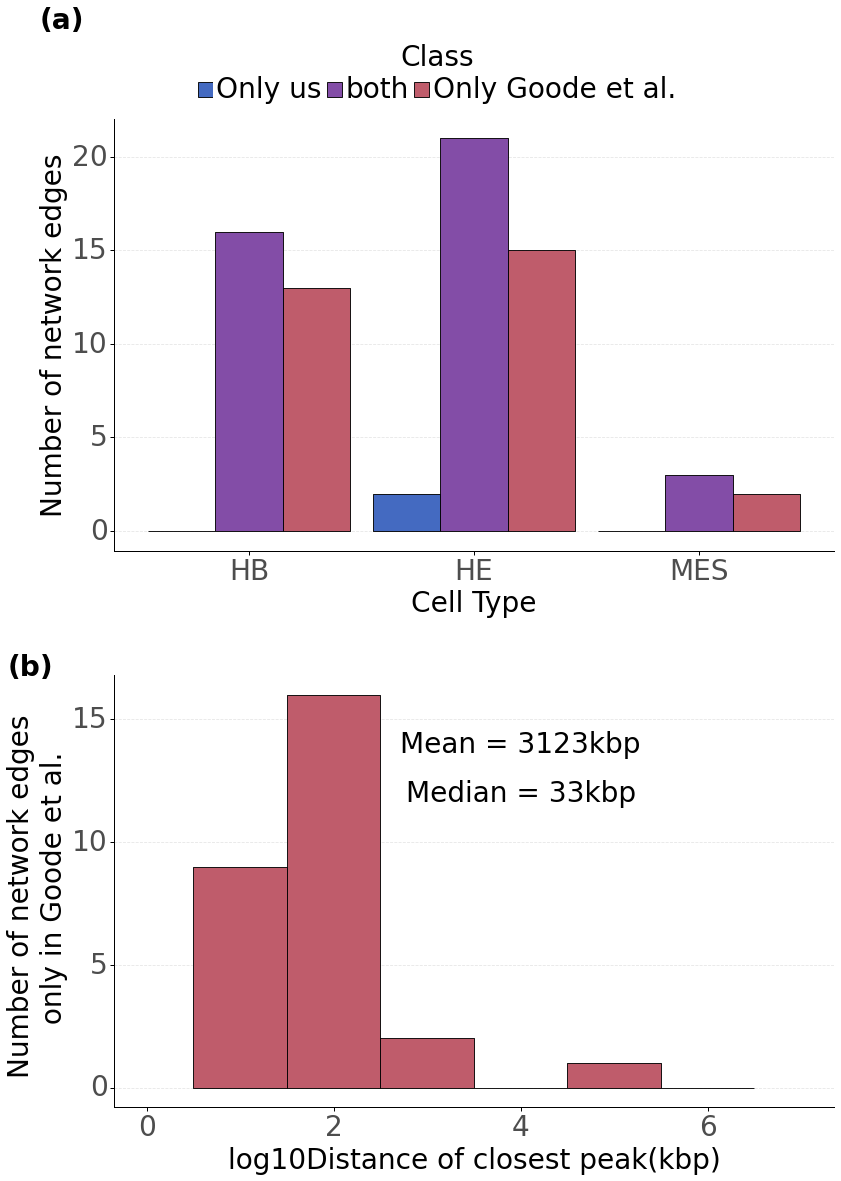

In [21]:
s4 = p_count/his
s4.savefig('../../../Figures/SFig4.pdf')